# Tarefa 1

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

treino = pd.read_csv("/kaggle/input/datasets/valdirscneto/atvd-ml/train.csv")
teste = pd.read_csv("/kaggle/input/datasets/valdirscneto/atvd-ml/test.csv")

# 1. Exibir as cinco primeiras linhas do treino
print("Cinco primeiras linhas do treino:")
display(treino.head())

# 2. Descobrir a quantidade de linhas e colunas em cada arquivo
print(f"Dimensões do treino (linhas, colunas): {treino.shape}")
print(f"Dimensões do teste (linhas, colunas): {teste.shape}")

Cinco primeiras linhas do treino:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dimensões do treino (linhas, colunas): (891, 12)
Dimensões do teste (linhas, colunas): (418, 11)


# Tarefa 2

--- Tipos e Nomes das Colunas ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

--- Valores Ausentes por Coluna ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Distribuição de Sobreviventes ---
Quantidade:
Survived
0    549
1    342
Name: count, dtype: int64

Proporção (%):
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

--- Gráficos Comparativos ---


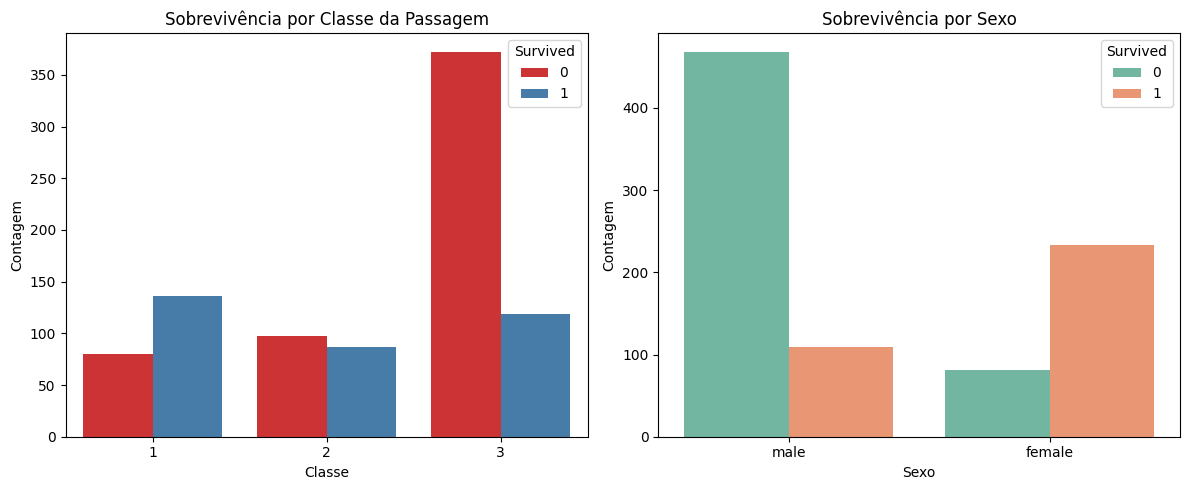

In [9]:
# a) Nomes e tipos das colunas
print("--- Tipos e Nomes das Colunas ---")
print(treino.dtypes)

# b) Quantos valores ausentes existem em cada coluna
print("\n--- Valores Ausentes por Coluna ---")
print(treino.isnull().sum())

# c) Quantidade e proporção de sobreviventes
qtd_sobreviventes = treino['Survived'].value_counts()
prop_sobreviventes = treino['Survived'].value_counts(normalize=True) * 100

print("\n--- Distribuição de Sobreviventes ---")
print(f"Quantidade:\n{qtd_sobreviventes}")
print(f"\nProporção (%):\n{prop_sobreviventes.round(2)}")

# Gráfico comparativo: Sobrevivência por Sexo e Classe
print("\n--- Gráficos Comparativos ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=treino, x='Pclass', hue='Survived', palette='Set1', ax=axes[0])
axes[0].set_title('Sobrevivência por Classe da Passagem')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Contagem')

sns.countplot(data=treino, x='Sex', hue='Survived', palette='Set2', ax=axes[1])
axes[1].set_title('Sobrevivência por Sexo')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Contagem')

plt.tight_layout()
plt.show()

### Escreva duas observações baseadas nos números ou no gráfico.
Morreram muito mais pessoas da terceira classe em comparação com a primeira e segunda classes. Também, pode-se observar que morreram mais pessoas do sexo masculino do que do sexo feminino.

# Tarefa 3

In [10]:
caracteristicas = [
    "Pclass", "Sex",
    "Age", "SibSp",
    "Parch", "Fare",
    "Embarked"
]

X = treino[caracteristicas]
y = treino["Survived"]

print(f"Formato da matriz de atributos X (linhas, colunas): {X.shape}")
print(f"Formato do vetor alvo y (linhas, colunas): {y.shape}")

Formato da matriz de atributos X (linhas, colunas): (891, 7)
Formato do vetor alvo y (linhas, colunas): (891,)


# Tarefa 4

In [11]:
from sklearn.model_selection import train_test_split

X_treino, X_val, y_treino, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Amostras de Treino: {X_treino.shape[0]}")
print(f"Amostras de Validação: {X_val.shape[0]}")

Amostras de Treino: 712
Amostras de Validação: 179


### Explique com suas palavras por que avaliar o modelo exatamente nos mesmos dados usados para treiná-lo pode gerar uma impressão enganosa de qualidade.
Avaliar o modelo nos dados já vistos gera uma falsa sensação de desempenho porque o algoritmo pode simplesmente "decorar" particularidades e ruídos do conjunto de treinamento (sobreajuste ou overfitting), em vez de generalizar padrões reais. Ter uma base de validação separada permite medir como o modelo reage diante de dados inéditos.

# Tarefa 5

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Separação das colunas numéricas e categóricas
colunas_numericas = ["Age", "SibSp", "Parch", "Fare"]
colunas_categoricas = ["Pclass", "Sex", "Embarked"]

# Pipeline numérico: substitui ausentes pela mediana
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline categórico: substitui ausentes pela moda e aplica OneHotEncoding
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Junção dos pré-processadores
preparador = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, colunas_numericas),
    ('cat', pipeline_categorico, colunas_categoricas)
])

print("Dados preparados.")

Dados preparados.


# Tarefa 6

In [13]:
from sklearn.linear_model import LogisticRegression

# Criação do pipeline completo com pré-processamento e estimador
modelo_pipeline = Pipeline(steps=[
    ('preparador', preparador),
    ('classificador', LogisticRegression(max_iter=1000, random_state=42))
])

# Treinamento apenas com os dados de treino
modelo_pipeline.fit(X_treino, y_treino)

# Geração das predições para o conjunto de validação
y_pred = modelo_pipeline.predict(X_val)

print("Treinamento finalizado e previsões geradas.")

Treinamento finalizado e previsões geradas.


# Tarefa 7

• Acurácia obtida: 0.8045
• Acertos na validação: 144
• Erros na validação: 35
  - Falsos Positivos (era 0, previu 1): 12
  - Falsos Negativos (era 1, previu 0): 23


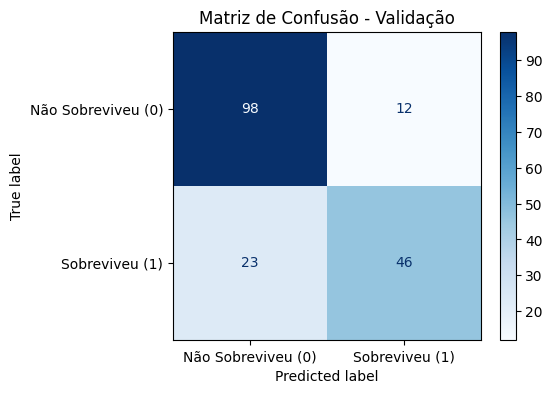

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

acuracia = accuracy_score(y_val, y_pred)
matriz = confusion_matrix(y_val, y_pred)

# Exibição numérica
tn, fp, fn, tp = matriz.ravel()
erros = fp + fn
acertos = tp + tn

print(f"• Acurácia obtida: {acuracia:.4f}")
print(f"• Acertos na validação: {acertos}")
print(f"• Erros na validação: {erros}")
print(f"  - Falsos Positivos (era 0, previu 1): {fp}")
print(f"  - Falsos Negativos (era 1, previu 0): {fn}")

# Visualização gráfica da matriz de confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matriz, display_labels=['Não Sobreviveu (0)', 'Sobreviveu (1)']).plot(ax=ax, cmap='Blues')
plt.title("Matriz de Confusão - Validação")
plt.show()

### Relatório de Avaliação:
* Acurácia obtida: 0.80
* Acertos ma validação: 144
* Erros na validação: 35

### O modelo errou mais sobreviventes ou não sobreviventes?
O modelo errou mais os **não sobreviventes**.